<a href="https://colab.research.google.com/github/alexmordashov/computer_math/blob/master/9.%20%D0%93%D0%B5%D0%BD%D0%B5%D1%80%D0%B0%D1%86%D0%B8%D1%8F%20%D1%81%D0%B8%D0%B3%D0%BD%D0%B0%D0%BB%D0%BE%D0%B2%20%D0%B8%20%D0%BF%D1%80%D0%B5%D0%BE%D0%B1%D1%80%D0%B0%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D1%8F%20%D0%A4%D1%83%D1%80%D1%8C%D0%B5/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%969_%D0%93%D0%B5%D0%BD%D0%B5%D1%80%D0%B0%D1%86%D0%B8%D1%8F_%D1%81%D0%B8%D0%B3%D0%BD%D0%B0%D0%BB%D0%BE%D0%B2_%D0%B8_%D0%BF%D1%80%D0%B5%D0%BE%D0%B1%D1%80%D0%B0%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D1%8F_%D0%A4%D1%83%D1%80%D1%8C%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №9. Генерация сигналов и преобразования Фурье

# Блок №1. Базовый уровень

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq, fftshift
from scipy.signal import spectrogram
from scipy import signal

## **Задание 1: Генерация сигналов**



В этом задании вам нужно создать различные виды сигналов. Сигналы являются основой цифровой обработки сигналов, и умение их генерировать является важным навыком.













1. **Синусоидальный сигнал**: Синусоидальный сигнал можно представить как $A \sin(2\pi ft + \phi)$, где $A$ - амплитуда, $f$ - частота, $\phi$ - фаза.

- Создайте функцию, которая принимает эти параметры, а также длительность сигнала, и возвращает сгенерированный сигнал.

### Пример:



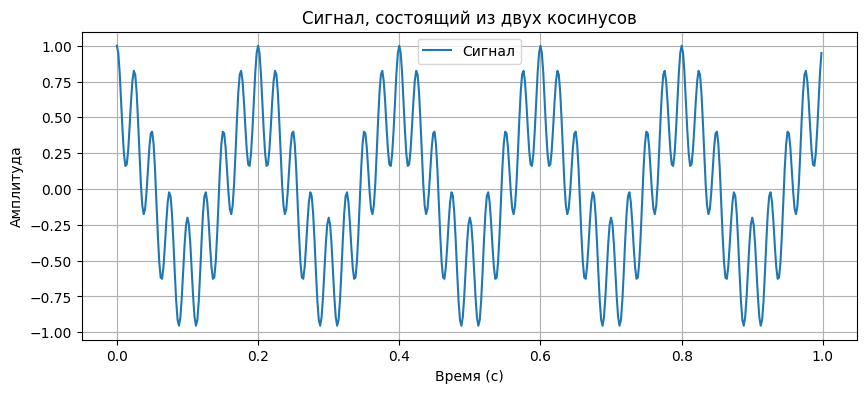

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Параметры времени
T = 1.0         # длительность сигнала в секундах
fs = 500.0      # частота дискретизации (в герцах)
t = np.arange(0, T, 1/fs) # массив времени

# Создание сигнала
f1 = 5.0        # частота первого косинуса
f2 = 40.0       # частота второго косинуса
a1 = 0.6        # амплитуда первого косинуса
a2 = 0.4        # амплитуда второго косинуса
signal = a1*np.cos(2*np.pi*f1*t) + a2*np.cos(2*np.pi*f2*t)

# Визуализация сигнала
plt.figure(figsize=(10, 4))
plt.plot(t, signal, label='Сигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Cигнал, состоящий из двух косинусов')
plt.legend()
plt.grid(True)
plt.show()


### Ваш код:

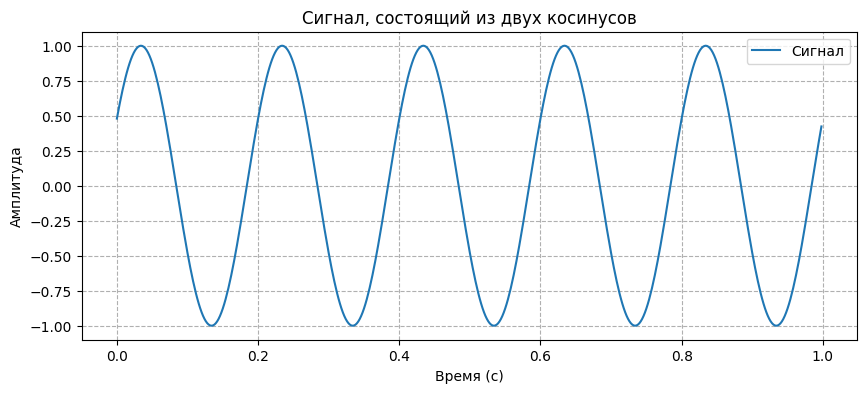

In [2]:
def gen_sig(A, f, fi, t_):
  return A * np.sin(2 * np.pi * f * t_ + fi)

T = 1.0
fs = 500.0
t = np.arange(0, T, 1/fs)
signal = gen_sig(1.0, 5.0, 0.5, t)

plt.figure(figsize=(10, 4))
plt.plot(t, signal, label='Сигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Cигнал, состоящий из двух косинусов')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

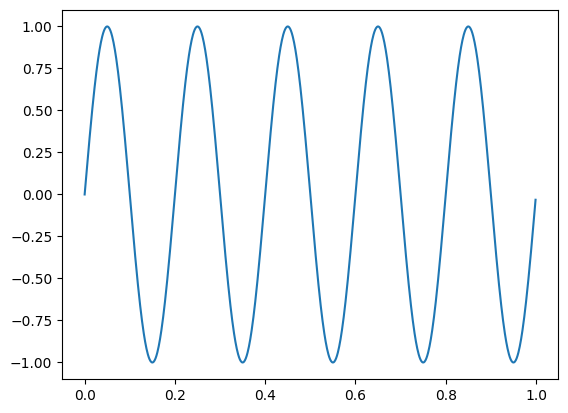

In [ ]:
# Пример

2. **Сумма синусоид**: Сигнал, состоящий из суммы двух синусоид, можно представить как $A_1 \sin(2\pi f_1t + \phi_1) + A_2 \sin(2\pi f_2t + \phi_2)$.

- Создайте функцию, которая принимает параметры для двух синусоид, а также длительность сигнала, и возвращает сгенерированный сигнал.

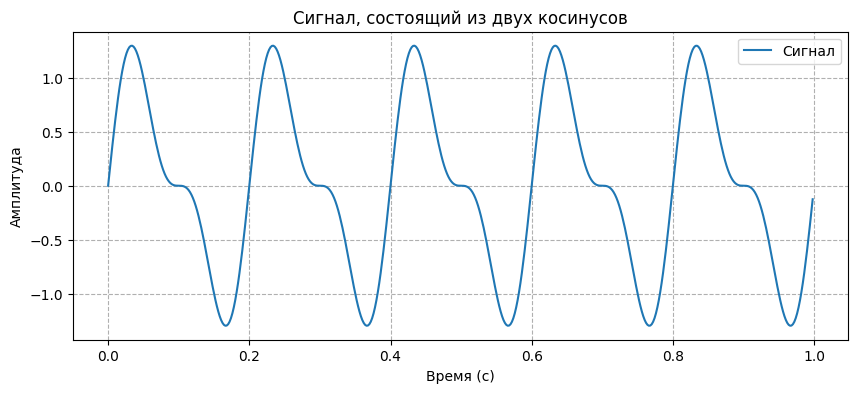

In [3]:
def gen_sum_sin(a1_, a2_, f1_, f2_, phi1_, phi2_, t_):
  return a1_ * np.sin(2 * np.pi * f1_ * t_ + phi1_) + a2_ * np.sin(2 * np.pi * f2_ * t_ + phi2_)

T = 1.0
fs = 500.0
t = np.arange(0, T, 1/fs)
f1 = 5.0
f2 = 10.0
a1 = 1.0
a2 = 0.5
phi1 = 0
phi2 = 0
signal_sum = gen_sum_sin(a1, a2, f1, f2, phi1, phi2, t)

plt.figure(figsize=(10, 4))
plt.plot(t, signal_sum, label='Сигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Cигнал, состоящий из двух косинусов')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

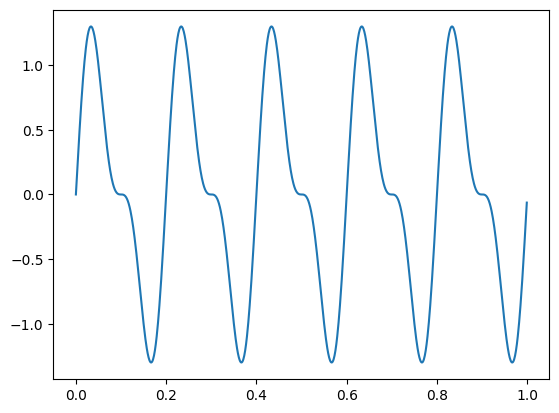

In [ ]:
# Пример

3. **Шумовой сигнал**: Шумовой сигнал (или белый шум) можно сгенерировать как случайные значения из нормального распределения.

- Создайте функцию, которая принимает амплитуду шума и длительность сигнала, и возвращает сгенерированный шумовой сигнал.

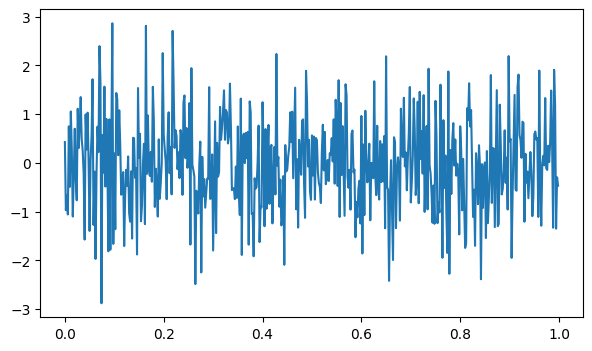

In [4]:
def gen_noise_sig(noise_amp, t_):
  return noise_amp * np.random.randn(len(t_))

T = 1.0
fs = 500.0
t = np.arange(0, T, 1/fs)
noise_amplitude = 1.0
noise_sig = gen_noise_sig(noise_amplitude, t)

plt.figure(figsize=(7, 4))
plt.plot(t, noise_sig)
plt.show()

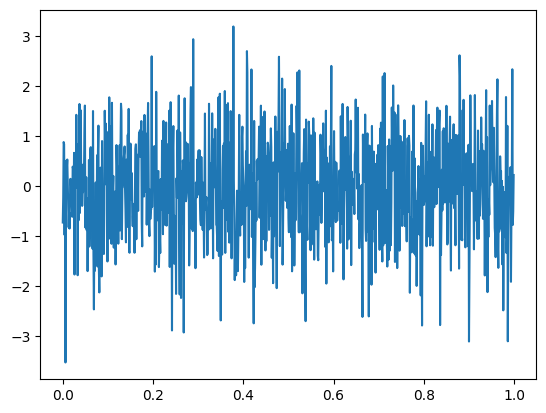

In [ ]:
# Пример

4. **Синусоида плюс шум**: Сигнал, который представляет собой сумму синусоиды и шума, можно сгенерировать путем сложения синусоидального и шумового сигналов.
- Создайте функцию, которая принимает параметры для синусоиды и шума, а также длительность сигнала, и возвращает сгенерированный сигнал.

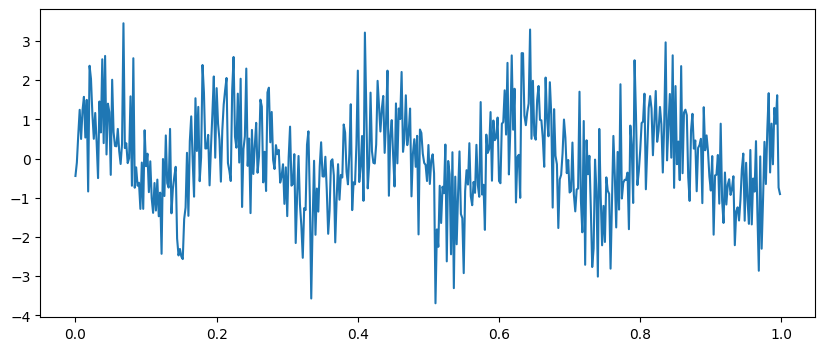

In [5]:
def gen_noise_sig(A_, f_, phi_, noise_amp, t_):
  sinusoid = A_ * np.sin(2 * np.pi * f_ * t_ + phi_)
  noise = noise_amp * np.random.randn(len(t_))
  return sinusoid + noise

T = 1.0
fs = 500.0
t = np.arange(0, T, 1/fs)
noise_amplitude = 1.0
A = 1.0
f = 5.0
phi = 0.5
noise_sin_sig = gen_noise_sig(A, f, phi, noise_amplitude, t)

plt.figure(figsize=(10, 4))
plt.plot(t, noise_sin_sig)
plt.show()

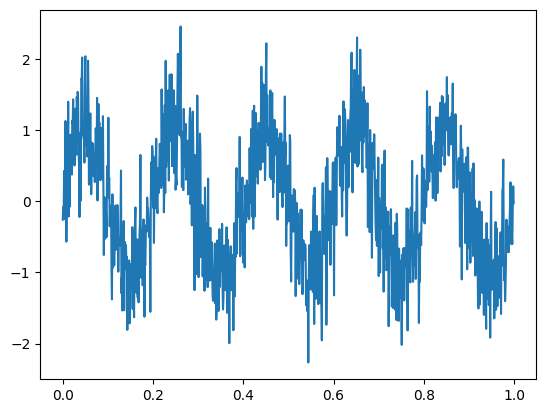

In [ ]:
# Пример

## **Задание 2: Преобразование Фурье**


Преобразование Фурье позволяет перейти от временного представления сигнала к частотному. Это основной инструмент для анализа сигналов. Создайте функцию, которая принимает сигнал и возвращает его преобразование Фурье.


1. Примените преобразование Фурье к синусоидальному сигналу и визуализируйте результат.


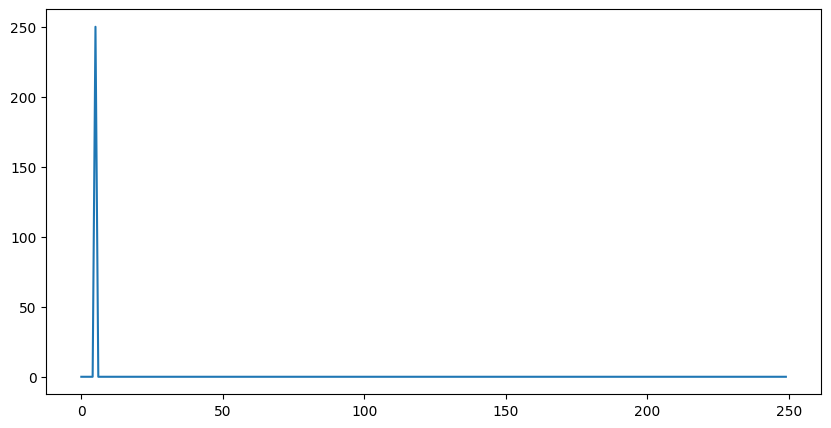

In [6]:
n = len(signal)
fft_result = fft(signal)
frequencies = fftfreq(n, 1 / fs)

plt.figure(figsize=(10, 5))
plt.plot(frequencies[:n // 2], np.abs(fft_result)[:n // 2])
plt.show()

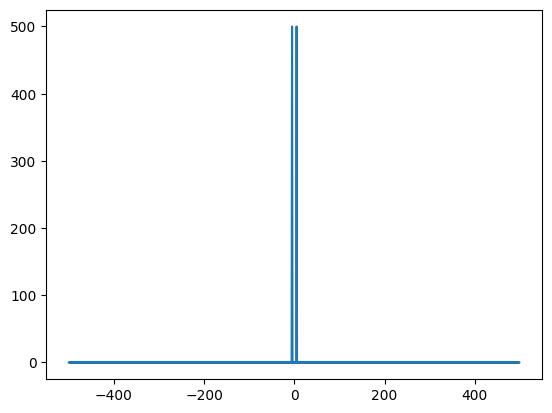

In [ ]:
# Пример

2. Примените преобразование Фурье к сигналу, состоящему из суммы двух синусоид, и визуализируйте результат.


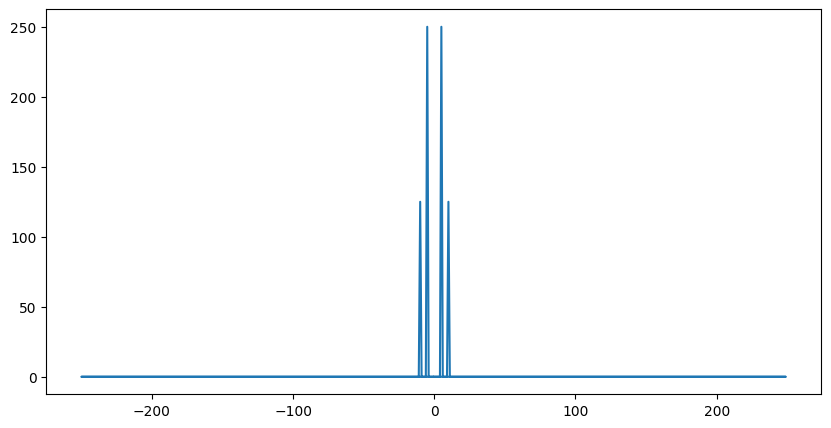

In [8]:
n = len(signal_sum)
fft_result = fft(signal_sum)
frequencies = fftfreq(n, 1 / fs)

plt.figure(figsize=(10, 5))
plt.plot(frequencies, np.abs(fft_result))
plt.show()

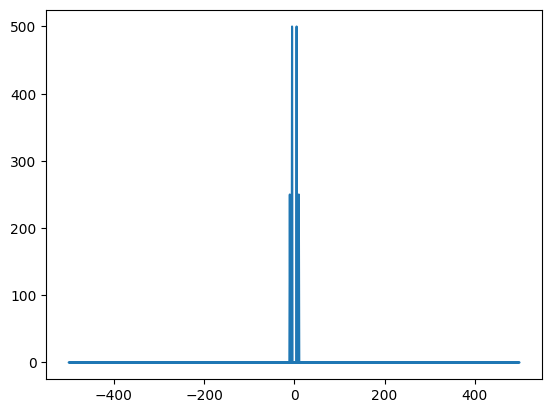

In [ ]:
# Пример

3. Примените преобразование Фурье к шумовому сигналу и визуализируйте результат.


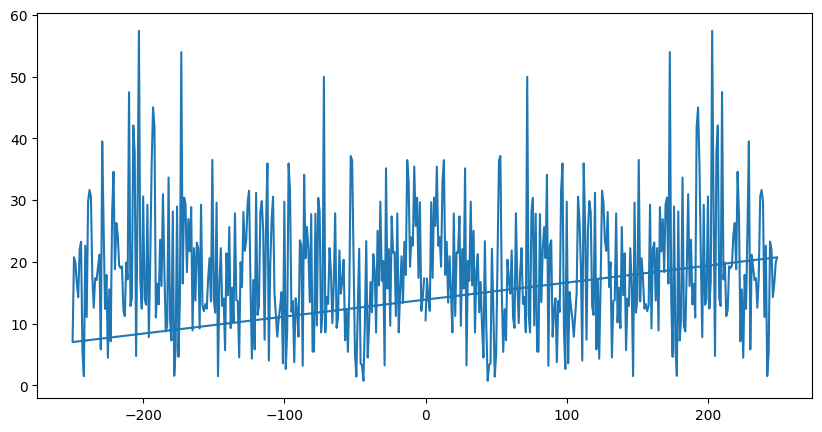

In [10]:
n = len(noise_sig)
fft_result = fft(noise_sig)
frequencies = fftfreq(n, 1 / fs)
#idx = np.argsort(frequencies)

plt.figure(figsize=(10, 5))
plt.plot(frequencies, np.abs(fft_result))
#plt.plot(frequencies[idx], np.abs(fft_result[idx]))
plt.show()

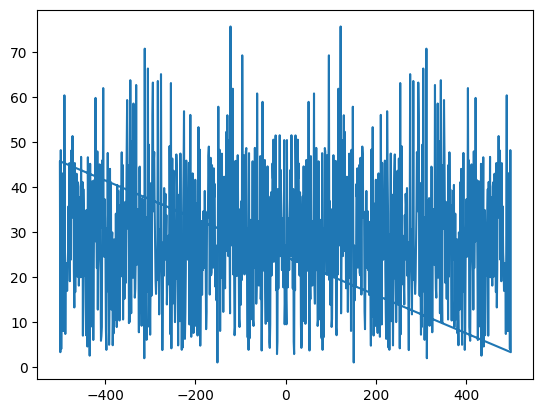

In [ ]:
# Пример

4. Примените преобразование Фурье к сигналу, который представляет собой сумму синусоиды и шума, и визуализируйте результат.

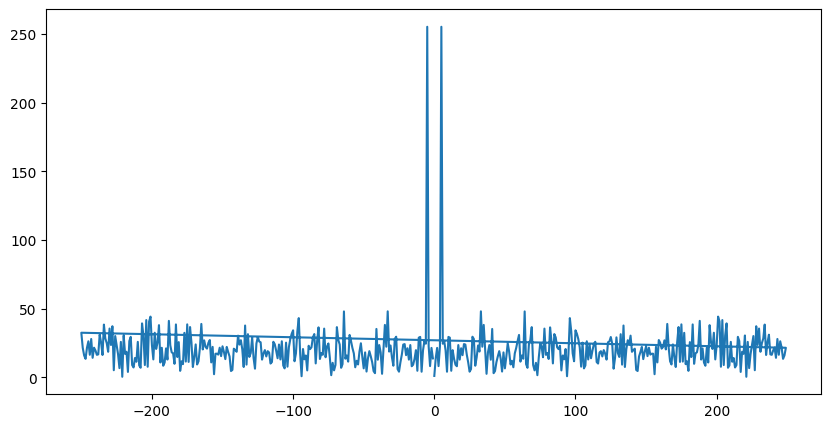

In [11]:
n = len(noise_sin_sig)
fft_result = fft(noise_sin_sig)
frequencies = fftfreq(n, 1 / fs)

plt.figure(figsize=(10, 5))
plt.plot(frequencies, np.abs(fft_result))
plt.show()

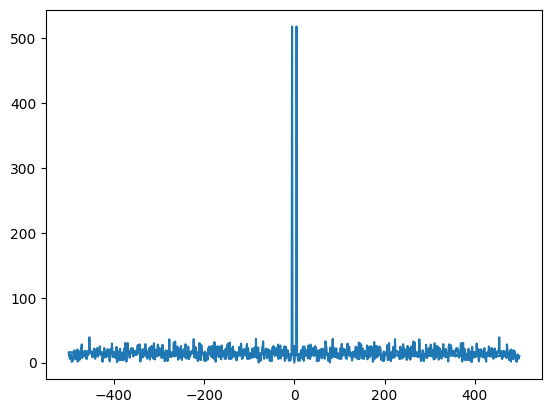

In [ ]:
# Пример

## **Задание 3: Фильтрация сигналов**

Фильтрация сигналов позволяет улучшить качество сигнала, убрав нежелательные частоты. Создайте функцию, которая принимает сигнал и частоту среза, и возвращает отфильтрованный сигнал.




1. Создайте функцию для фильтрации сигнала с использованием преобразования Фурье.

In [12]:
def filter_sig(sig, cutoff, fs_):
  n = len(sig)
  fft_result = fft(sig)
  frequencies = fftfreq(n, 1 / fs_)
  fft_filter = fft_result.copy()
  fft_filter[np.abs(frequencies) > cutoff] = 0
  filtered_signal = np.real(ifft(fft_filter))
  return filtered_signal

In [ ]:
# Пример

2. Примените эту функцию к сигналу, который представляет собой сумму синусоиды и шума, и визуализируйте результаты до и после фильтрации.

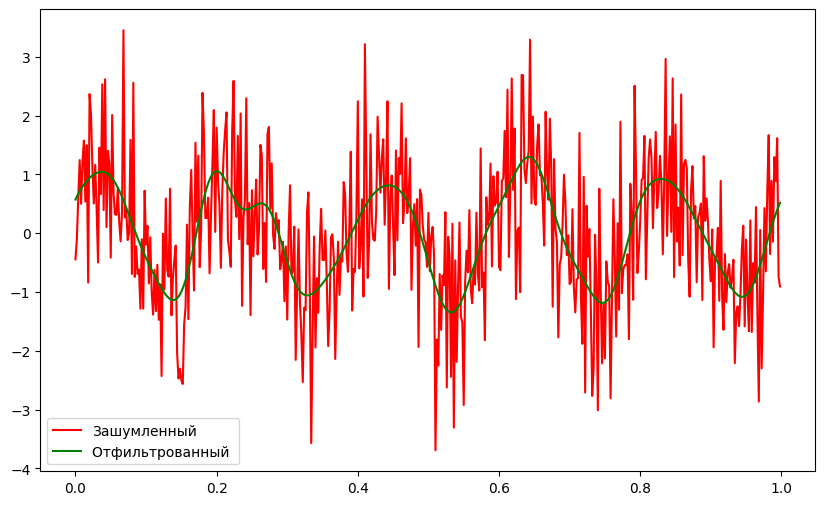

In [13]:
cutoff = 15
filtered_signal = filter_sig(noise_sin_sig, cutoff, fs)
plt.figure(figsize=(10, 6))
plt.plot(t, noise_sin_sig, color='red', label='Зашумленный')
plt.plot(t, filtered_signal, color='green', label='Отфильтрованный ')
plt.legend()
plt.show()

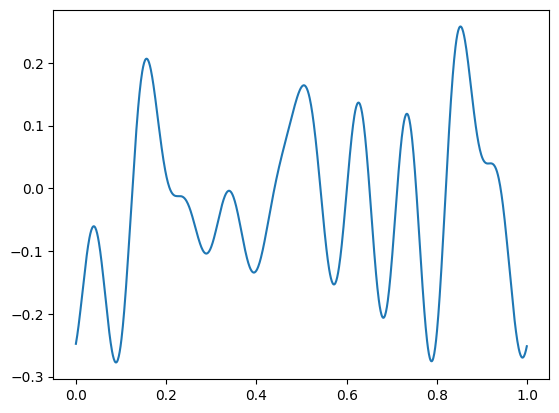

In [ ]:
# Пример

## **Задание 4: Анализ сигналов**

Анализ сигналов включает в себя различные методы и техники для изучения и понимания сигналов. Создайте функцию, которая принимает сигнал и возвращает его спектрограмму (**scipy.signal.spectrogram**).


**Спектрограмма** - это визуальное представление спектра частот сигнала во времени. Она показывает, какие частоты присутствуют в сигнале в каждый момент времени. Вот как правильно понимать спектрограмму:

- **Ось X**: Это время. Она показывает продолжительность сигнала. Каждый столбец на спектрограмме представляет собой отдельный момент времени.

- **Ось Y**: Это частота. Она показывает различные частоты, которые присутствуют в сигнале. Каждая строка на спектрограмме представляет собой отдельную частоту.

- **Значение**: Значение в каждой точке (x, y) показывает амплитуду (или интенсивность) данной частоты в данное время. Обычно более яркие цвета означают большую амплитуду, а более темные цвета - меньшую амплитуду.

Таким образом, спектрограмма позволяет вам видеть, как меняется спектральный состав сигнала во времени. Это может быть полезно во многих областях, включая анализ речи, музыку, радиосигналы и многое другое. Например, в анализе речи вы можете видеть, как меняются форманты (основные частоты) во время произношения различных звуков. В музыке вы можете видеть, как меняются ноты во время проигрывания песни.

1. Создайте функцию для вычисления и визуализации спектрограммы сигнала.


In [14]:
def disp_spectrogram(sig, fs_):
  f_, t_, Sxx = spectrogram(sig, fs_)
  plt.figure(figsize=(10, 6))
  plt.pcolormesh(t_, f_, 10 * np.log10(Sxx), shading='gouraud', cmap='viridis')
  plt.xlabel('Time [sec]')
  plt.ylabel('Frequency [Hz]')
  plt.colorbar(label='Intensity [dB]')
  plt.show()

2. Примените эту функцию к различным сигналам, которые вы сгенерировали и проанализировали в предыдущих заданиях.

Анализ синусоидального сигнала:
Анализ сигнала 'сумма синусоид':


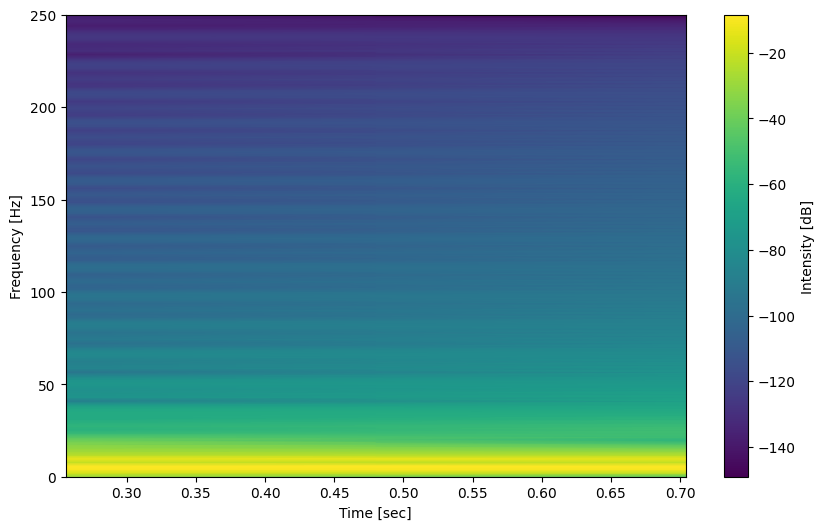

Анализ шумового сигнала:


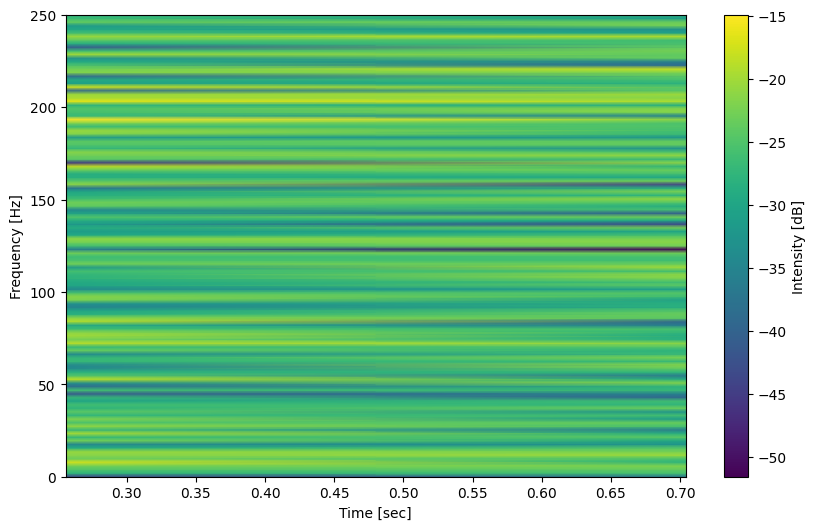

Анализ сигнала 'cинусоида + шум':


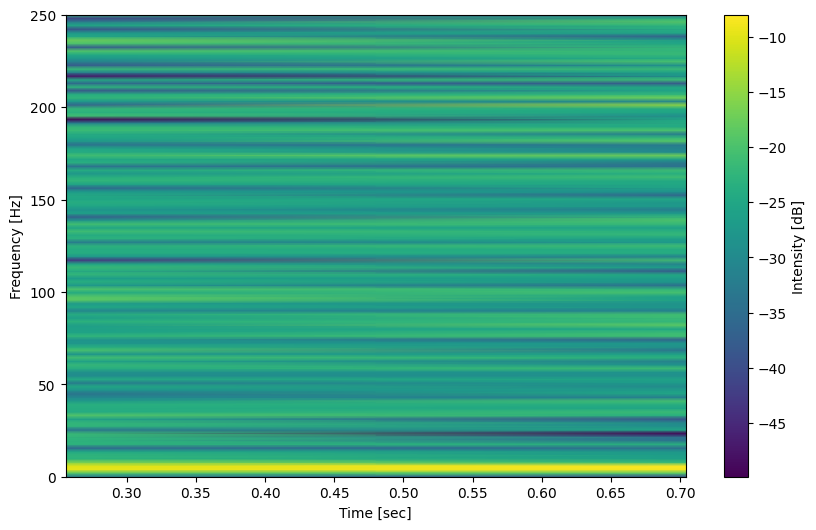

Анализ отфильтрованного сигнала 'cинусоида + шум':


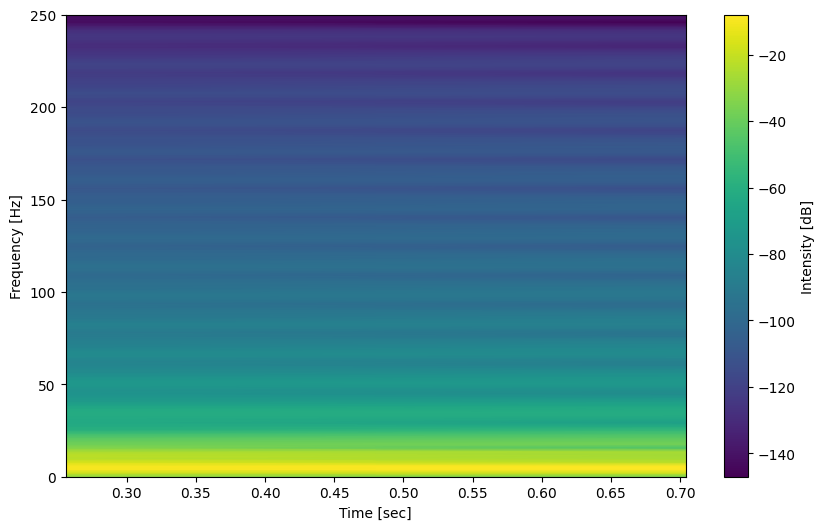

In [15]:
print("Анализ синусоидального сигнала:")
#disp_spectrogram(signal, fs)
print("Анализ сигнала 'сумма синусоид':")
disp_spectrogram(signal_sum, fs)
print("Анализ шумового сигнала:")
disp_spectrogram(noise_sig, fs)
print("Анализ сигнала 'cинусоида + шум':")
disp_spectrogram(noise_sin_sig, fs)
print("Анализ отфильтрованного сигнала 'cинусоида + шум':")
disp_spectrogram(filtered_signal, fs)

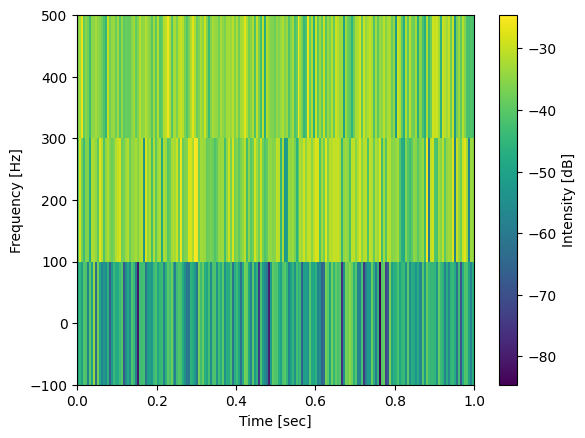

In [ ]:
# Пример

# Блок №2. Повышенный уровень

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from scipy.io import wavfile

## **Задание 1: Чтение и визуализация звукового файла**











В этом задании вам нужно использовать функцию `wavfile.read` из модуля `scipy.io` для чтения звукового файла. Эта функция возвращает частоту дискретизации и данные аудиосигнала. Затем вы должны визуализировать эти данные с помощью `matplotlib.pyplot.plot`. В результате вы получите график амплитуды звукового сигнала во времени.

1. Используйте библиотеку `scipy.io.wavfile` для чтения звукового файла.

In [33]:
filename = "lebedi.wav"
sek, data = wavfile.read(filename)
if len(data.shape) > 1:
    data = data[:, 0]

2. Визуализируйте временную форму звукового сигнала.

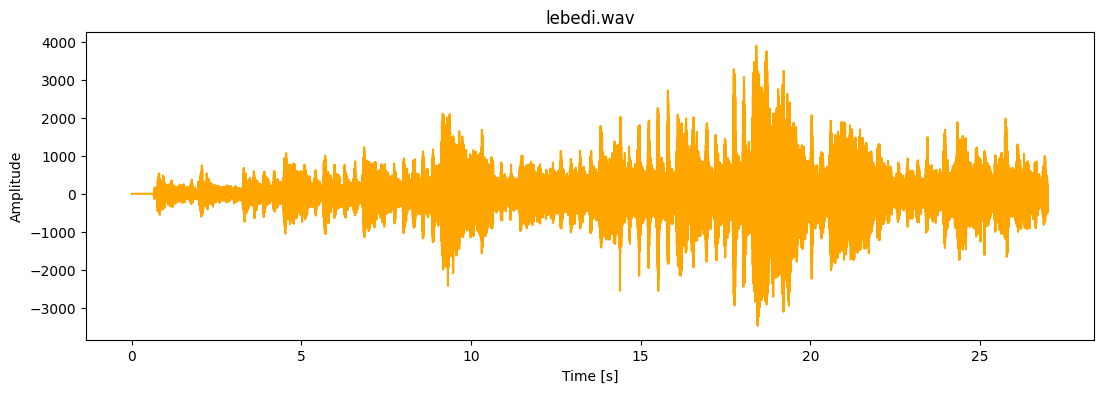

In [34]:
t = np.arange(len(data)) / sek
plt.figure(figsize=(13, 4))
plt.plot(t, data, color='orange')
plt.title(filename)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.show()

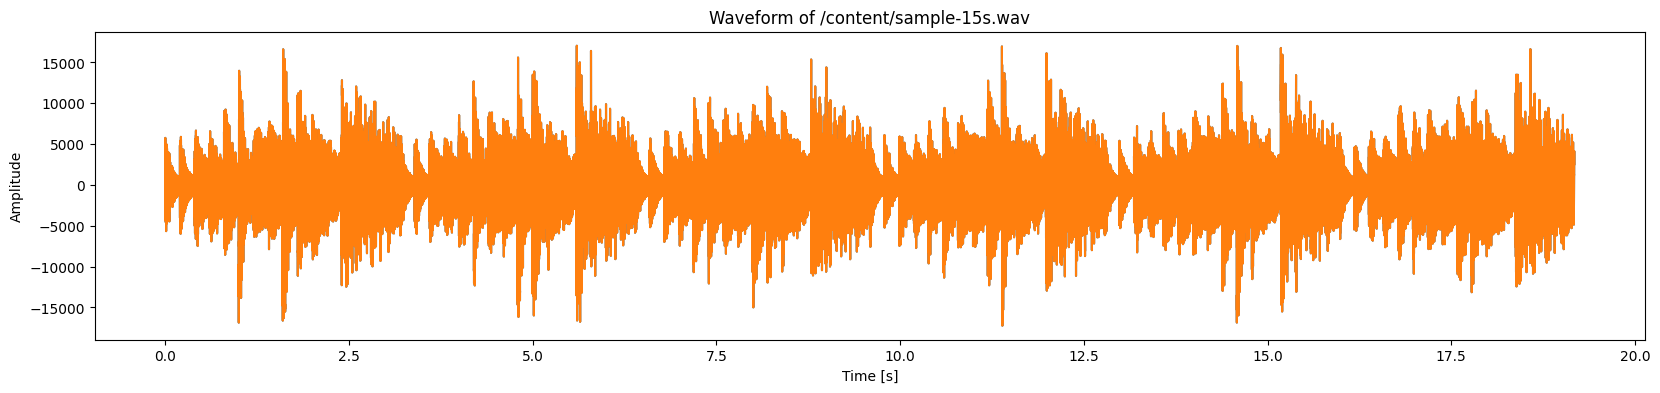

In [ ]:
# Пример

## **Задание 2: Применение преобразования Фурье**



Преобразование Фурье позволяет перейти от временного представления сигнала к частотному. Для его применения вы можете использовать функцию `fft` из модуля `scipy.fft`. Эта функция возвращает комплексные коэффициенты преобразования Фурье, которые затем можно визуализировать.

1. Примените преобразование Фурье к звуковому сигналу и визуализируйте спектр.

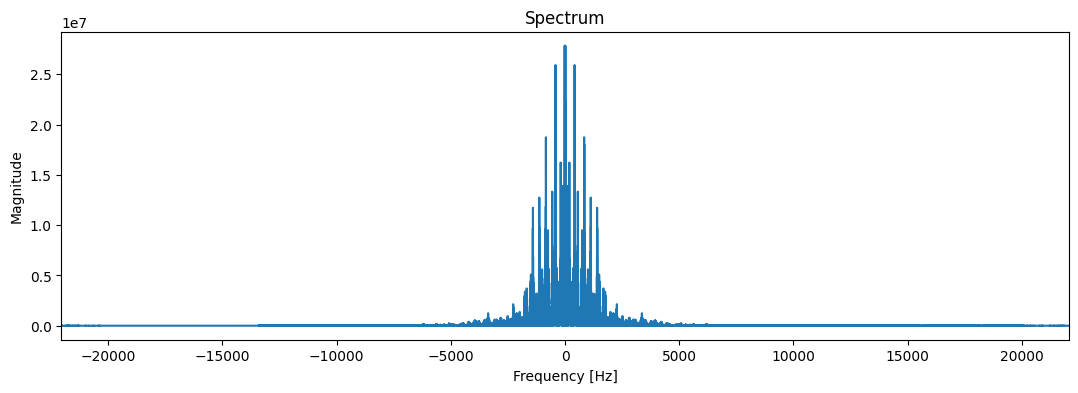

In [35]:
n = len(data)
fft_result = fft(data)
frequencies = fftfreq(n, 1/sek)
idx = np.argsort(frequencies)
freq_sorted = frequencies[idx]
fft_sorted = np.abs(fft_result[idx])
plt.figure(figsize=(13, 4))
plt.plot(freq_sorted, fft_sorted)
plt.title('Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.xlim(freq_sorted[0], freq_sorted[-1])
plt.show()

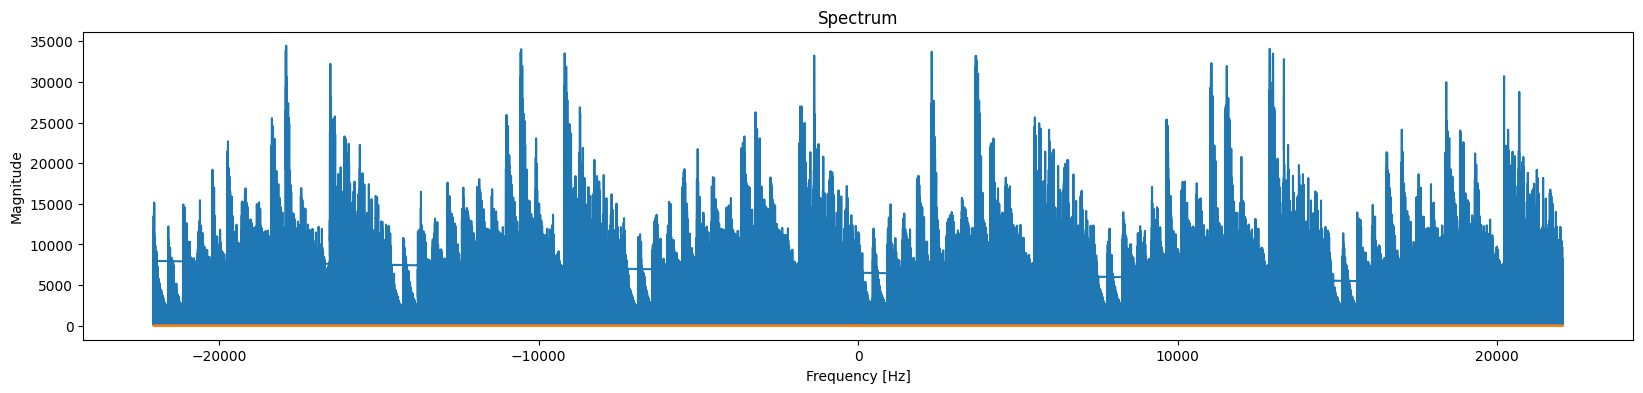

In [ ]:
# Пример

## **Задание 3: Фильтрация сигнала**



Фильтрация сигнала позволяет улучшить качество звука, убрав нежелательные частоты. Для этого вы можете использовать преобразование Фурье, затем обнулить некоторые из его коэффициентов и выполнить обратное преобразование Фурье с помощью функции `ifft` из модуля `scipy.fft`.

1. Создайте функцию для фильтрации сигнала с использованием преобразования Фурье.


In [36]:
def filter_sig_fur(audio_, cutoff_freq, sek_):
    n = len(audio_)
    fft_result = fft(audio_)
    frequencies = fftfreq(n, 1/sek_)
    fft_filtered = fft_result.copy()
    fft_filtered[np.abs(frequencies) > cutoff_freq] = 0
    filtered_audio = np.real(ifft(fft_filtered))
    return filtered_audio.astype(audio_.dtype)

2. Примените эту функцию к звуковому сигналу и визуализируйте результаты до и после фильтрации.

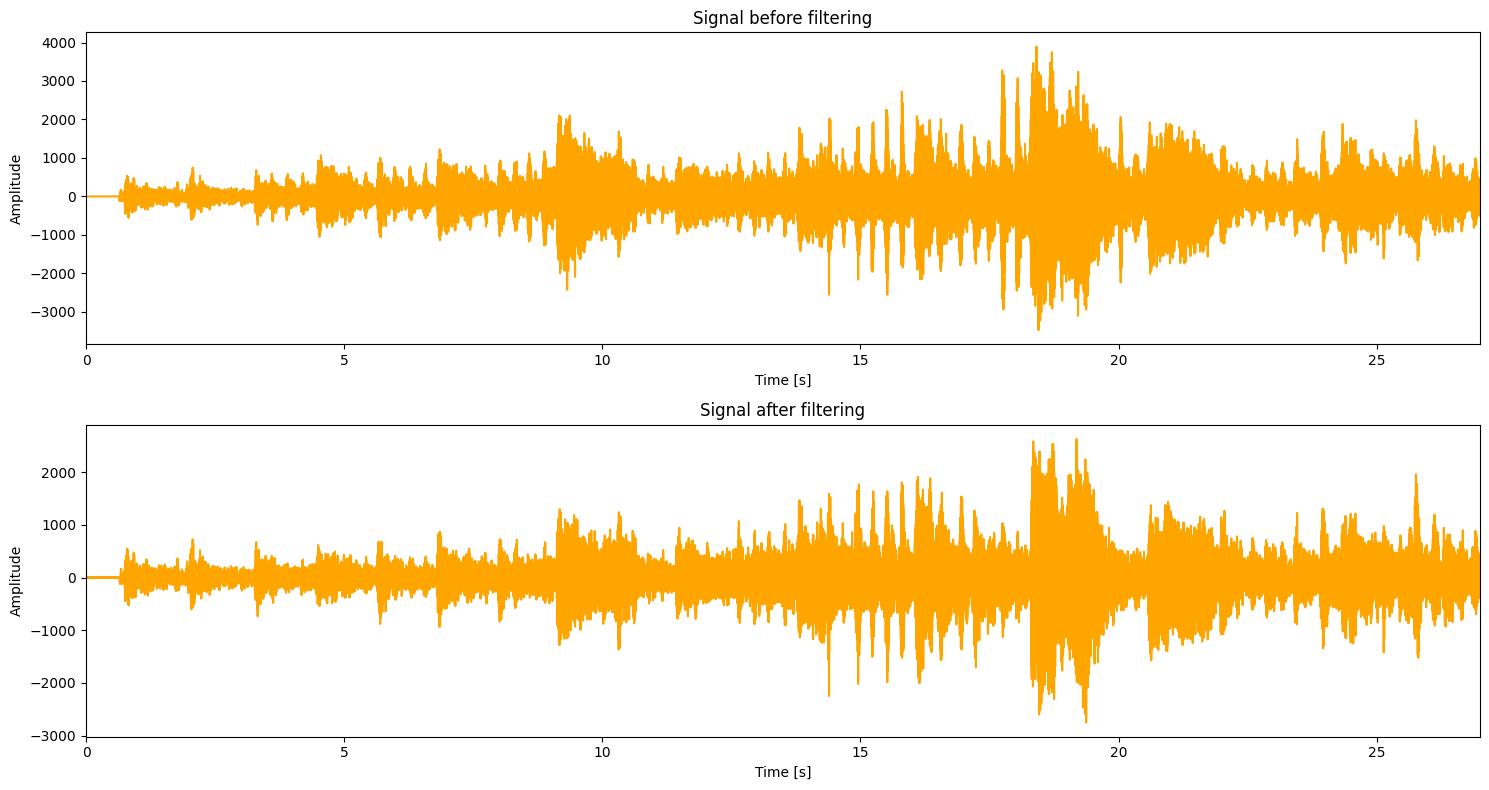

In [38]:
cutoff = 1000.0
filtered_data = filter_sig_fur(data, cutoff, sek)
t = np.arange(len(data)) / sek
plt.figure(figsize=(15, 8))
plt.subplot(2, 1, 1)
plt.plot(t, data, color='orange')
plt.title('Signal before filtering')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.xlim(0, t[-1])
plt.subplot(2, 1, 2)
plt.plot(t, filtered_data, color='orange')
plt.title(f'Signal after filtering')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.xlim(0, t[-1])
plt.tight_layout()
plt.show()

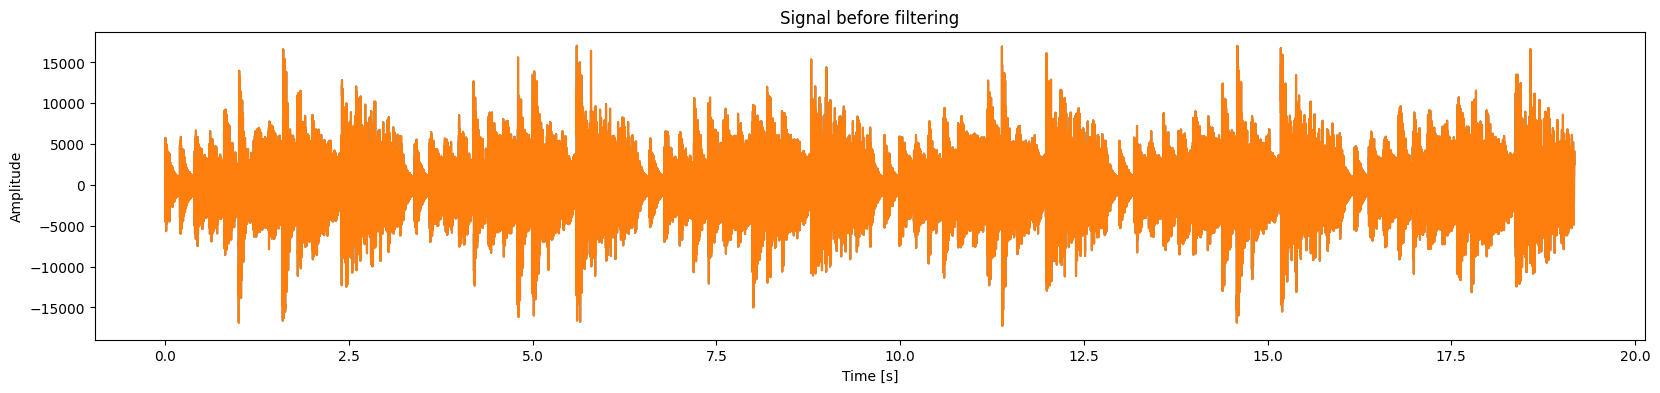

In [ ]:
# Визуализация сигнала до фильтрации

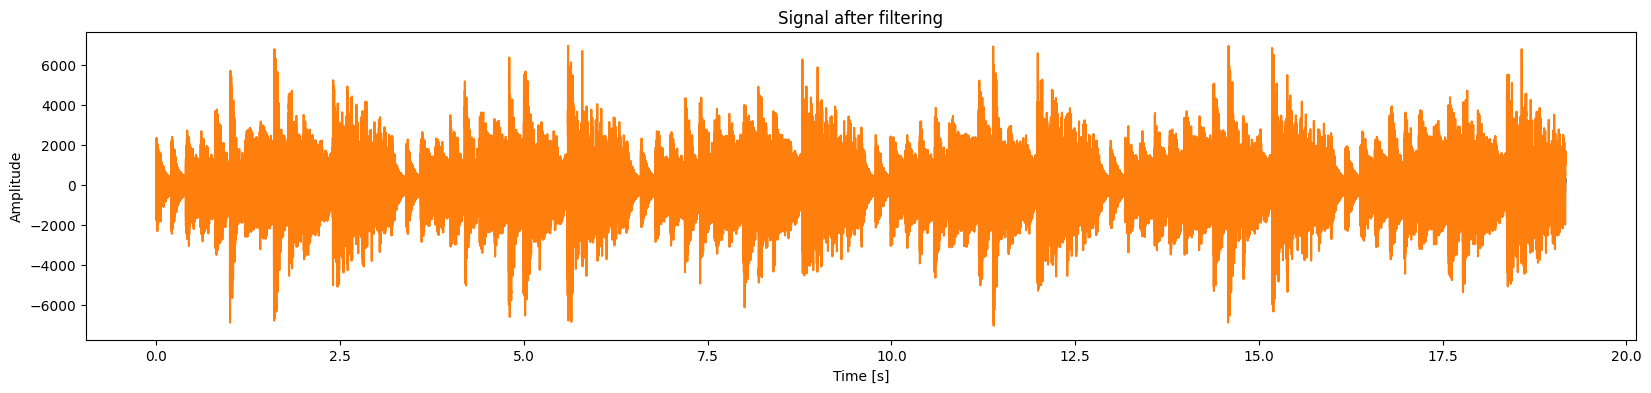

In [ ]:
# Визуализация сигнала после фильтрации

## **Задание 4: Обратное преобразование Фурье**



После фильтрации сигнала вы можете применить обратное преобразование Фурье для получения отфильтрованного звукового сигнала во временной области. Затем вы можете сохранить этот сигнал в новый звуковой файл с помощью функции `wavfile.write` из модуля `scipy.io`.

1. Примените обратное преобразование Фурье к отфильтрованному сигналу.


In [41]:
n = len(data)
fft_result = fft(data)
frequencies = fftfreq(n, 1/sek)
cutoff = 1000.0
fft_filtered = fft_result.copy()
fft_filtered[np.abs(frequencies) > cutoff] = 0
recovered_signal = np.real(ifft(fft_filtered))
final_audio = recovered_signal.astype(data.dtype)

2. Сохраните полученный сигнал в новый звуковой файл.

In [42]:
output_filename = f"{filename[:-4]}_filtered.wav"
wavfile.write(output_filename, sek, final_audio)